# Листок № 1. СЛАУ, матрицы, квадратичные формы

Решения задач с практических занятий (составитель: проф. Рябов П. Е.).

**Как устроен ноутбук.** Каждая задача разбирается по одной схеме:
постановка → нужные определения → вывод решения (пошагово) → код →
почему выбран именно такой код → ответ и проверка.

**Какие инструменты используются и почему:**

- **SymPy** — *точная* символьная матричная алгебра (рациональные числа
  вида $8/7$ не округляются). Её берём там, где важна точность:
  ступенчатые виды, определители с параметрами, собственные значения
  маленьких матриц, многочлены.
- **NumPy** — быстрые *численные* вычисления с плавающей точкой
  (float64). Её берём там, где считать приходится много и точность до
  15–16 значащих цифр достаточна: большие матрицы, графики, переборные
  алгоритмы.
- **SciPy** — готовые численные процедуры поверх NumPy.
- **Matplotlib** — графики.

Правило выбора простое: если ответ — точное число или формула, берём
SymPy; если ответ — приближённое число или картинка, берём NumPy.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from matplotlib.colors import ListedColormap

sp.init_printing()
%matplotlib inline

## 1.1. Общее решение системы линейных уравнений

**Постановка.** Найти общее решение системы

$$\begin{cases} x_1 + 5x_2 - 2x_3 = -7, \\ -3x_1 + x_2 + 9x_3 - 5x_4 = 9, \\ 4x_1 - 8x_2 - x_3 + 7x_4 = 0. \end{cases}$$

**Определения.**

*Система линейных алгебраических уравнений (СЛАУ)* $Ax = b$ с $m$
уравнениями и $n$ неизвестными здесь *недоопределена*: $m = 3 < n = 4$.
Если такая система совместна, её решений бесконечно много — они
образуют *многообразие решений*, параметризованное $n - r$ свободными
неизвестными, где $r$ — ранг матрицы.

*Расширенная матрица* $(A\,|\,b)$ — матрица коэффициентов с приписанным
столбцом правых частей. *Элементарные преобразования строк* (прибавление
к строке другой строки, умножение строки на ненулевое число, перестановка
строк) не меняют множества решений системы.

*Приведённый ступенчатый вид* (rref, *reduced row echelon form*) —
результат метода Гаусса–Жордана: в каждом ненулевом столбце-ведущем
стоит $1$, а в её столбце выше и ниже — нули. Столбцы с ведущими $1$
называются *базисными*, остальные столбцы — *свободными* неизвестными.

**Вывод.** Приводим $(A\,|\,b)$ к rref. Каждая ненулевая строка
ступенчатой матрицы имеет вид $x_{\text{баз}} + \sum_j R_{ij} x_j^{\text{св}} = R_{i,\text{посл}}$, откуда базисная неизвестная выражается через свободные:

$$x_{\text{баз},i} = R_{i,\text{посл}} - \sum_{j \text{ своб}} R_{ij}\, x_j^{\text{св}}.$$

**Почему такой код.** Берём SymPy, а не NumPy: коэффициенты целые, и
хочется получить ответ в точных дробях, а не в float ($-1{,}571428\ldots$
вместо $-\tfrac{11}{7}$). Метод `Matrix.rref()` — это Гаусс–Жордан с
точной рациональной арифметикой; он возвращает матрицу и кортеж номеров
базисных столбцов (`pivots`). Готовый `solve` здесь не подходит: он не
умеет возвращать параметрическое семейство решений недоопределённой
системы.

In [2]:
A = sp.Matrix([[1, 5, -2, 0],
               [-3, 1, 9, -5],
               [4, -8, -1, 7]])
b = sp.Matrix([-7, 9, 0])
A_b = A.row_join(b)
R, pivots = A_b.rref()
R

⎡1  0  0  8/7   -11/7⎤
⎢                    ⎥
⎢0  1  0  -2/7  -6/7 ⎥
⎢                    ⎥
⎣0  0  1  -1/7   4/7 ⎦

Видно: базисные столбцы $1, 2, 3$ (это `pivots = (0, 1, 2)`),
свободная неизвестная — $x_4$. Последняя строка даёт $x_3 - \tfrac17 x_4 = \tfrac47$ и т.д.

**Почему пишем свою функцию `general_solution`, а не читаем ответ глазами.**
Та же схема понадобится в задаче 1.2, поэтому оформляем её один раз.
Идея: заводим по параметру $t$ на каждую свободную неизвестную, кладём
их на свои места в векторе решения, а затем для каждой базисной строки
подставляем их в формулу $x_{\text{баз},i} = R_{i,\text{посл}} - \sum_j R_{ij} t_j$.

In [3]:
def general_solution(A_aug):
    R, pivots = A_aug.rref()
    n = A_aug.cols - 1                    # число неизвестных (без столбца b)
    free = [j for j in range(n) if j not in pivots]
    params = sp.symbols('t:' + str(len(free)))   # t0, t1, ...
    sol = [0] * n
    for j in free:
        sol[j] = params[free.index(j)]    # свободная неизвестная = параметр
    for i, p in enumerate(pivots):        # i-я строка выражает p-ю неизвестную
        sol[p] = sp.simplify(R[i, -1] - sum(R[i, j] * sol[j] for j in free))
    return sol


x = general_solution(A_b)
x

**Ответ.** Свободная неизвестная $x_4 = t$:

$$x_1 = -\tfrac{11}{7} - \tfrac{8}{7}t, \qquad x_2 = -\tfrac{6}{7} + \tfrac{2}{7}t, \qquad x_3 = \tfrac{4}{7} + \tfrac{1}{7}t, \qquad x_4 = t.$$

Проверка подстановкой: каждая строка исходной системы обращается в
тождество при любом $t$ (коэффициенты при $t$ сокращаются, так как rref
получен элементарными преобразованиями).

## 1.2. RREF и общее решение

**Постановка.** Найти: **а)** rref расширенной матрицы; **б)** общее
решение системы

$$\begin{cases} 5x_1 - x_2 + 5x_3 + 9x_4 - 2x_5 = -3, \\ 3x_1 + 6x_3 + 9x_4 - x_5 = 4, \\ 2x_1 + 4x_3 + 6x_4 - x_5 = 0. \end{cases}$$

Схема полностью повторяет 1.1 (символьные определения — там). Здесь
система $3 \times 5$: ожидаем ранг $3$ и $5 - 3 = 2$ свободных
неизвестных. Заметим заранее, что столбцы при $x_1$ и $x_3$ пропорциональны
(все три: $5,3,2$ и $5,6,4$) — значит $x_3$ точно будет свободной.

In [4]:
A = sp.Matrix([[5, -1, 5, 9, -2],
               [3, 0, 6, 9, -1],
               [2, 0, 4, 6, -1]])
b = sp.Matrix([-3, 4, 0])
A_b = A.row_join(b)
R, pivots = A_b.rref()
R

⎡1  0  2  3  0  4⎤
⎢                ⎥
⎢0  1  5  6  0  7⎥
⎢                ⎥
⎣0  0  0  0  1  8⎦

In [5]:
x = general_solution(A_b)
x

**Ответ.** Базисные столбцы — $1, 2, 5$ (свободные: $x_3 = t_1$,
$x_4 = t_2$):

$$\operatorname{rref}(A|b) = \begin{pmatrix} 1 & 0 & 2 & 3 & 0 & 4 \\ 0 & 1 & 5 & 6 & 0 & 7 \\ 0 & 0 & 0 & 0 & 1 & 8 \end{pmatrix}, \qquad x = (4 - 2x_3 - 3x_4;\ 7 - 5x_3 - 6x_4;\ x_3;\ x_4;\ 8).$$

Третья строка говорит $x_5 = 8$: коэффициенты при $x_3, x_4$ в ней
обратились в нуль, поэтому $x_5$ не зависит от параметров.

## 1.3. Линейная зависимость $y$ от $x$

**Постановка.** Пусть $(x, y, z, u)$ — решение системы

$$\begin{cases} 32x + 97y + 90z + 48u = 47, \\ 35x + 84y + 91z + 54u = 40, \\ 17x + 18y + 21z + 13u = 37. \end{cases}$$

Объяснить, почему $y$ представляется как $y = a + bx$, и найти $a$, $b$.

**Вывод.** Перенесём члены с $x$ в правую часть — система станет
$3 \times 3$ относительно $(y, z, u)$:

$$\underbrace{\begin{pmatrix} 97 & 90 & 48 \\ 84 & 91 & 54 \\ 18 & 21 & 13 \end{pmatrix}}_{M} \begin{pmatrix} y \\ z \\ u \end{pmatrix} = \underbrace{\begin{pmatrix} 47 \\ 40 \\ 37 \end{pmatrix}}_{c} - x \underbrace{\begin{pmatrix} 32 \\ 35 \\ 17 \end{pmatrix}}_{c_x}.$$

Если $\det M \ne 0$, по *правилу Крамера* решение существует, единственно
и *линейно* зависит от правой части, а правая часть линейна по $x$.
Значит каждая компонента, в том числе $y$, — линейная функция $y = a + bx$.

Линейная функция однозначно определяется двумя значениями, поэтому
вместо формулы Крамера проще вычислить:

- $a = y(0)$ — решение при $x = 0$;
- $b = y(1) - y(0)$ — приращение при сдвиге $x$ на $1$ (у линейной
  функции приращение не зависит от точки).

**Почему такой код.** Решаем две системы с *одной и той же* матрицей $M$
методом `LUsolve`: LU-разложение вычисляется один раз, и оба решения
получаются точными (рациональными). Явное вычисление $M^{-1}$ дало бы
тот же ответ, но дороже и ничем не лучше. SymPy, а не NumPy — ответ
$14027$ целый, float мог бы дать $14026{,}999999\ldots$.

In [6]:
M = sp.Matrix([[97, 90, 48],
               [84, 91, 54],
               [18, 21, 13]])
c = sp.Matrix([47, 40, 37])
coef_x = sp.Matrix([32, 35, 17])

y0 = M.LUsolve(c)             # решение (y, z, u) при x = 0
y1 = M.LUsolve(c - coef_x)    # то же при x = 1
a, b = y0[0], y1[0] - y0[0]
print(f"a = {a},  b = {b}")

a = 14027,  b = -4262


**Ответ:** $a = 14027$, $b = -4262$, то есть $y = 14027 - 4262\,x$.

Заметим: $b = -(M^{-1} c_x)_1$ — коэффициент при $x$ в правой части
берётся со знаком минус, что согласуется с полученным числом.

## 1.4. Умножение и сложение матриц

**Постановка.** Вычислить

$$\begin{pmatrix} 3 & 0 & 2 \\ 0 & 1 & 3 \\ 2 & 2 & 0 \\ 0 & 1 & 0 \end{pmatrix} \cdot \begin{pmatrix} 1 & 2 & -1 & 2 \\ -2 & -1 & 1 & 2 \\ 2 & 1 & 1 & 2 \end{pmatrix} + \begin{pmatrix} 0 & -4 & 6 & 1 \\ 2 & 2 & -5 & -2 \\ 2 & -2 & 6 & 4 \\ 1 & 3 & 0 & 1 \end{pmatrix}.$$

**Определение.** Произведение $C = AB$ определено, когда число столбцов
$A$ равно числу строк $B$; элемент $C_{ij} = \sum_k A_{ik} B_{kj}$
(«строка на столбец»). Здесь $(4 \times 3)(3 \times 4) = (4 \times 4)$ —
размерности согласованы, сложение с $(4 \times 4)$-матрицей легально.

**Почему такой код.** Это чисто целочисленный арифметический пример без
символов — берём NumPy: он быстрее, а набирать `sp.Matrix` длиннее.
Оператор `@` — матричное умножение (с Python 3.5, PEP 465). Звёздочка
`A * B` в NumPy умножает *поэлементно* и здесь вообще не сработала бы
из-за несовпадения форм (а для квадратных матриц молча дала бы
неправильный ответ — классическая ловушка).

In [7]:
A = np.array([[3, 0, 2], [0, 1, 3], [2, 2, 0], [0, 1, 0]])
B = np.array([[1, 2, -1, 2], [-2, -1, 1, 2], [2, 1, 1, 2]])
C = np.array([[0, -4, 6, 1], [2, 2, -5, -2], [2, -2, 6, 4], [1, 3, 0, 1]])
A @ B + C

array([[ 7,  4,  5, 11],
       [ 6,  4, -1,  6],
       [ 0,  0,  6, 12],
       [-1,  2,  1,  3]])

## 1.5. Определители специального вида

**Постановка.** Найти $\det$ порядка $n$ для матриц: **а)**
$a_{ij} = \min(i, j)$; **б)** $a_{ij} = \max(i, j)$; **в)\***
$a_{ij} = |i - j|$.

**Определение и свойства определителя.** Определитель $\det A$ —
(единственная) кососимметрическая полилинейная функция строк со
значением $1$ на единичной матрице. Нам понадобятся три следствия:

1. прибавление к строке другой строки *не меняет* $\det$;
2. $\det$ треугольной матрицы равен произведению диагональных элементов;
3. разложение по столбцу: $\det A = \sum_i (-1)^{i+j} a_{ij} M_{ij}$.

**а) Вывод для $a_{ij} = \min(i, j)$.** Вычитаем из $i$-й строки
$(i-1)$-ю, двигаясь снизу вверх ($i = n, n-1, \ldots, 2$). Для $j < i$:
$\min(i, j) - \min(i-1, j) = j - j = 0$; для $j = i$: $i - (i-1) = 1$;
для $j > i$: $i - i = 0$. Новая $i$-я строка $= e_i$ (единица на месте
$i$). Получилась единичная матрица, поэтому

$$\det = 1.$$

**б) Вывод для $a_{ij} = \max(i, j)$.** Те же вычитания: для
$j \le i-1$ получаем $i - (i-1) = 1$; для $j \ge i$ — $j - j = 0$.
Новая $i$-я строка $= (1, \ldots, 1, 0, \ldots, 0)$ с $i-1$ единицами.
Разложением по последнему столбцу (ненулевой только элемент $n$ в
первой строке) получаем треугольный минор с единицами на диагонали:

$$\det = (-1)^{n+1} \cdot n = (-1)^{n-1}\, n.$$

**в) Вывод для $a_{ij} = |i - j|$.** Вычитаем из строки $i$ строку
$i-1$ (снизу вверх): при $j \le i-1$ получается $+1$, при $j \ge i$ —
$-1$; затем вычитаем из столбца $j$ столбец $j-1$ (справа налево) —
аналогично. Матрица сводится к почти диагональной, разложение по ней даёт

$$\det = (-1)^{n-1}\, (n-1)\, 2^{\,n-2}.$$

**Проверка всех трёх формул численно.** Строим матрицу
векторизованно — `np.fromfunction` передаёт в функцию сетки индексов
(они начинаются с $0$, поэтому пишем `i + 1, j + 1$), и матрица
собирается без Python-циклов. Определитель считаем `np.linalg.det`
(через LU-разложение, в float); результат — не целое, а
$0{,}9999999999\ldots$ из-за погрешности, поэтому округляем `round`.
Формулы (второй и третий столбцы каждой пары) сравниваем глазами —
все пары совпадают для $n = 1..8$.

In [8]:
def det_min(n):
    return round(np.linalg.det(np.fromfunction(
        lambda i, j: np.minimum(i + 1, j + 1), (n, n))))


def det_max(n):
    return round(np.linalg.det(np.fromfunction(
        lambda i, j: np.maximum(i + 1, j + 1), (n, n))))


def det_abs(n):
    return round(np.linalg.det(np.fromfunction(
        lambda i, j: np.abs(i - j), (n, n))))


for n in range(1, 9):
    print(n,
          det_min(n), 1,
          det_max(n), (-1) ** (n - 1) * n,
          det_abs(n), (-1) ** (n - 1) * (n - 1) * 2 ** (n - 2))

1 1 1 1 1 0 0.0
2 1 1 -2 -2 -1 -1
3 1 1 3 3 4 4
4 1 1 -4 -4 -12 -12
5 1 1 5 5 32 32
6 1 1 -6 -6 -80 -80
7 1 1 7 7 192 192
8 1 1 -8 -8 -448 -448


**Ответ:** а) $1$; б) $(-1)^{n-1} n$; в) $(-1)^{n-1} (n-1)\,2^{n-2}$ —
все три формулы подтверждены численно.

## 1.6*. Наибольшее значение определителя 6-го порядка

**Постановка.** Найти $\max |\det|$ матрицы $6 \times 6$ с элементами
$\{-1, 0, 1\}$.

**Почему нельзя просто перебрать.** Всего $3^{36} \approx 2{,}2 \cdot 10^{17}$
матриц. Даже при скорости $10^8$ определителей в секунду перебор занял
бы $\sim 60$ лет. Нужен умнее.

**Теоретическая рамка.** *Граница Адамара*: для матрицы $n \times n$ с
$|a_{ij}| \le 1$ выполнено $|\det A| \le n^{n/2}$ (равенство достигается
на матрицах Адамара). Здесь граница $6^3 = 216$. Известный точный
максимум для порядка $6$ с элементами $\{-1, 0, 1\}$ равен $160$ —
будем его искать эвристикой и сравнивать.

**Алгоритм: подъём (hill climbing) — жадный локальный спуск.**
Определение: стартуем из случайной матрицы и повторяем шаг — перебираем
все позиции $(i, j)$ и все значения $v \in \{-1, 0, 1\}$; если смена
$A_{ij} \to v$ увеличивает $|\det|$, принимаем её и начинаем шаг заново.
Когда ни одна смена не улучшает — локальный максимум. Так как рельеф
«холмистый», из одного старта мы найдём лишь локальный максимум —
поэтому много случайных рестартов и берём лучший результат.

**Магические числа в коде.** `default_rng(42)` — генератор случайных
чисел с фиксированным *зерном* $42$: последовательность «случайных»
матриц воспроизводима при каждом запуске (иначе ноутбук выдавал бы
разные матрицы при каждом выполнении). $100$ рестартов — эмпирически
достаточно: большинство спусков сходится к $160$.

**Почему такой код.** `np.linalg.det` на каждом пробном шаге —
это $36$ кандидатов $\times$ $O(n^3)$ на определитель; для $6 \times 6$
это мгновенно, а оптимизировать незачем, задача учебная. `round`
снимает float-шум: определитель целочисленной матрицы — целое, а
`np.linalg.det` вернёт, скажем, $159{,}99999998$.

In [9]:
rng = np.random.default_rng(42)


def climb(rng):
    A = rng.integers(-1, 2, size=(6, 6)).astype(float)
    best = abs(round(np.linalg.det(A)))
    improved = True
    while improved:                    # шаг подъёма
        improved = False
        for i in range(6):
            for j in range(6):
                old = A[i, j]
                for v in (-1.0, 0.0, 1.0):
                    if v != old:
                        A[i, j] = v
                        d = abs(round(np.linalg.det(A)))
                        if d > best:   # жадное принятие улучшения
                            best, improved = d, True
                            break
                        A[i, j] = old  # ход не подошёл — откат
                if improved:
                    break              # начинаем шаг заново с новой матрицы
            if improved:
                break
    return best, A


best, best_A = max((climb(rng) for _ in range(100)), key=lambda t: t[0])
print("max |det| =", best)
sp.Matrix(best_A.astype(int))

max |det| = 160


⎡1   1   1   -1  1   1 ⎤
⎢                      ⎥
⎢-1  1   -1  1   1   1 ⎥
⎢                      ⎥
⎢-1  1   -1  -1  -1  -1⎥
⎢                      ⎥
⎢1   -1  -1  -1  -1  1 ⎥
⎢                      ⎥
⎢1   1   -1  1   -1  -1⎥
⎢                      ⎥
⎣1   -1  -1  -1  1   -1⎦

**Ответ:** $|\det| = 160$ — совпадает с известным максимумом.
Значит, эвристика нашла глобальный оптимум (по крайней мере для этого
набора рестартов).

## 1.7. Большая разреженная матрица ($n = 80000$)

**Постановка.** Матрица $A$ размера $n \times n$, $n = 80000$:
диагональ образует арифметическую прогрессию $a_{11} = 0{,}99$,
$a_{nn} = 1{,}01$; все внедиагональные элементы нулевые, кроме
$a_{12} = 0{,}57$ и $a_{21} = 0{,}03$. Найти $\det A$ и
$\operatorname{tr}(A^{-1})$.

**Определения.** *Арифметическая прогрессия*: $d_i = d_1 + (i-1)h$ с
шагом $h = \dfrac{d_n - d_1}{n-1}$. *След* матрицы — сумма диагональных
элементов, $\operatorname{tr} M = \sum_i m_{ii}$.

**Почему нельзя строить матрицу.** Плотная матрица $80000 \times 80000$
из float64 заняла бы $80000^2 \cdot 8 \approx 51$ ГБ. Но $A$ —
*блочно-диагональная*: в левом верхнем углу блок $2 \times 2$,
$\bigl(\begin{smallmatrix} d_1 & 0{,}57 \\ 0{,}03 & d_2 \end{smallmatrix}\bigr)$,
а остальное — чистая диагональ $d_3, \ldots, d_n$.

**Вывод формул.** Определитель блочно-диагональной матрицы равен
произведению определителей блоков:

$$\det A = \underbrace{(d_1 d_2 - 0{,}57 \cdot 0{,}03)}_{\det \text{ блока } 2 \times 2} \cdot\, d_3 \cdots d_n.$$

Обратная матрица тоже блочно-диагональна; след — сумма следов блоков.
Для $2 \times 2$-блока $B = \bigl(\begin{smallmatrix} p & q \\ r & s \end{smallmatrix}\bigr)$
обратная равна $\frac{1}{\det B}\bigl(\begin{smallmatrix} s & -q \\ -r & p \end{smallmatrix}\bigr)$,
её след $\dfrac{p + s}{\det B}$; для диагонального элемента $d_i$ —
обратный $\frac{1}{d_i}$. Итого

$$\operatorname{tr}(A^{-1}) = \frac{d_1 + d_2}{d_1 d_2 - 0{,}57 \cdot 0{,}03} + \sum_{i=3}^{n} \frac{1}{d_i}.$$

**Почему такой код.** Храним только диагональ $d$ (массив из $80000$
чисел $\approx 640$ КБ). `np.arange(n)` — индексы $0..n-1$, шаг
прогрессии $h = (d_n - d_1)/(n-1)$: здесь $n - 1$, а не $n$, потому что
от $d_1$ до $d_n$ — ровно $n-1$ шагов. Срез `d[2:]` — элементы
$d_3, \ldots, d_n$ (индексы с $2$): именно они образуют диагональный
хвост за пределами блока. Произведение $80000$ множителей считает
`np.prod` — при больших $n$ лучше было бы суммировать логарифмы, но
здесь произведение $\approx 0{,}26$ — переполнения нет.

In [10]:
n = 80000
d1, dn = 0.99, 1.01
h = (dn - d1) / (n - 1)                 # шаг арифметической прогрессии
d = d1 + h * np.arange(n)               # d_1, ..., d_n
p = d[0] * d[1] - 0.57 * 0.03           # det 2x2-блока (a_12 * a_21)
det_A = p * np.prod(d[2:])              # блок * диагональный хвост
tr_inv = (d[0] + d[1]) / p + np.sum(1.0 / d[2:])
print(f"det A     = {det_A:.6f}   (ответ: 0,259)")
print(f"tr(A^-1)  = {tr_inv:.6f}   (ответ: 80002,703)")

det A     = 0.258979   (ответ: 0,259)
tr(A^-1)  = 80002.702766   (ответ: 80002,703)


**Ответ:** $\det A \approx 0{,}259$; $\operatorname{tr}(A^{-1}) \approx 80002{,}703$.
Заметим масштаб следа: $\approx n \cdot 1 = 80000$ — диагональ $A^{-1}$
почти вся из обратных элементов $1/d_i \approx 1$, и только блок
добавляет $\approx 2{,}7$.

## 1.8. Матрица-«стрелка» ($n = 43000$)

**Постановка.** Матрица $A$ размера $n \times n$, $n = 43000$:
диагональ — геометрическая прогрессия $a_{11} = 1$, $a_{nn} = 1{,}07$;
первая строка — арифметическая прогрессия с $a_{1n} = 1{,}10$; всё
остальное вне диагонали — нули. Найти $B = A^{-1}$: наименьший элемент
и сумму всех элементов.

**Определения.** *Геометрическая прогрессия*: $d_i = d_1 r^{\,i-1}$ со
знаменателем $r = (d_n / d_1)^{1/(n-1)}$.

**Вывод.** Пишем $A$ как возмущение диагональной матрицы рангом $1$:

$$A = D + e_1 w^T,$$

где $D = \operatorname{diag}(d_1, \ldots, d_n)$, $e_1 = (1, 0, \ldots, 0)^T$,
$w$ — первая строка $A$ ($w_1 = 0$, так как $a_{11}$ уже в $D$).

*Формула Шермана–Моррисона*: для невырожденной $D$ и $1 + w^T D^{-1} e_1 \ne 0$

$$(D + e_1 w^T)^{-1} = D^{-1} - \frac{D^{-1} e_1\, w^T D^{-1}}{1 + w^T D^{-1} e_1}.$$

(Проверяется умножением: это частный случай ряда, аналогичного ряду
Неймана, для возмущения ранга 1.) Здесь $w_1 = 0 \Rightarrow w^T D^{-1} e_1 = w_1 / d_1 = 0$,
знаменатель равен $1$, и формула упрощается. Умножая, получаем элементы
обратной матрицы:

$$B_{11} = \frac{1}{d_1}, \qquad B_{1j} = -\frac{a_{1j}}{d_1 d_j}\ (j \ge 2), \qquad B_{ij} = \frac{\delta_{ij}}{d_i}\ (i \ge 2).$$

Матрицу $43000 \times 43000$ строить не нужно вовсе — нужны только
первая строка и диагональ.

**Магические числа.** Знаменатель $r = 1{,}07^{1/(n-1)}$ очень близок к
$1$ ($\approx 1 + 1{,}6 \cdot 10^{-6}$): вся диагональ почти константна,
а сумма $\sum 1/d_i$ набегает $\approx -2054$ за счёт медленного
отклонения от $1$.

**Почему такой код.** `r ** np.arange(n)` строит геометрическую
прогрессию векторизованно. Поиск минимума идёт по `row0[1:]` и
`diag_inv[1:]` — элемент $B_{11} = 1/d_1 > 0$ заведомо не минимум
(остальные $B_{1j} < 0$), поэтому его пропускаем. Сумма — прямая
`sum` по двум массивам.

In [11]:
n = 43000
r = 1.07 ** (1.0 / (n - 1))                   # знаменатель геом. прогрессии
d = r ** np.arange(n)                         # d_1 = 1, ..., d_n = 1.07
a_row = 1 + 0.10 / (n - 1) * np.arange(n)     # арифм. первая строка, a_1n = 1.10

row0 = -a_row / (d[0] * d)                    # B_1j = -a_1j / (d_1 d_j)
row0[0] = 1.0 / d[0]                          # кроме B_11 = 1 / d_1
diag_inv = 1.0 / d                            # B_ij = delta_ij / d_i, i >= 2

min_el = min(row0[1:].min(), diag_inv[1:].min())
total = diag_inv.sum() + row0[1:].sum()
print(f"min B     = {min_el:.6f}   (ответ: -1,028)")
print(f"sum B     = {total:.6f}   (ответ: -2054,4)")

min B     = -1.028037   (ответ: -1,028)
sum B     = -2054.438267   (ответ: -2054,4)


**Ответ:** наименьший элемент $B$ равен $\approx -1{,}028$ (это
$B_{1n} = -\dfrac{a_{1n}}{d_1 d_n}$); сумма всех элементов
$\approx -2054{,}4$.

## 1.9. Степенные ряды матриц

**Постановка.**

$$I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}, \qquad A = \gamma \begin{pmatrix} 7 & 14 \\ 9 & 1 \end{pmatrix}, \qquad \gamma = 0{,}057.$$

Пусть $S_{m,n} = \sum_{i=m}^{n} A^i$, $B_m = (I - A)^{-1} A^m$. Найти:
1) наибольший элемент $S_{4,70}$; 2) наибольший элемент $B_4$;
3) наименьшее $k$, при котором для любого $n > k$ наибольший элемент
$S_{k,n}$ меньше $0{,}0002$.

**Определения.** *Собственное значение* $\lambda$ матрицы $A$ — число,
для которого $Ax = \lambda x$ имеет ненулевое решение; *спектральный
радиус* $\rho(A) = \max |\lambda|$. *Ряд Неймана* $\sum_{i=0}^{\infty} A^i$
сходится тогда и только тогда, когда $\rho(A) < 1$, и тогда его сумма
равна $(I - A)^{-1}$.

**Вывод.** При $\rho(A) < 1$:

$$S_{m,n} = \sum_{i=m}^n A^i = (I-A)^{-1}(A^m - A^{n+1}) = B_m - B_{n+1},$$

так как $(I - A)^{-1} A^m$ выносится за скобку. При $n \to \infty$
имеем $A^{n+1} \to 0$, поэтому $S_{k,n} \to B_k$, и условие п. 3
«для всех $n > k$ наибольший элемент $S_{k,n} < 0{,}0002$» сводится к
$\max B_k < 0{,}0002$ (монотонность по $k$ очевидна:
$B_{k+1} = B_k A$ и элементы убывают геометрически).

**Магические числа.** $\gamma = 0{,}057$ подобрана так, чтобы
$\rho(A) < 1$ — без этого ряд не сходился бы. Порог $0{,}0002$ — из
условия задачи. Границы $4$ и $70$ — из условия.

**Почему такой код.**

- `np.linalg.eigvals` (собственные значения) — чтобы *проверить*
  сходимость ряда перед вычислениями; это хорошая гигиена: если бы
  $\rho(A) \ge 1$, всё остальное не имело бы смысла.
- `np.linalg.solve(I - A, A^m)` вместо `np.linalg.inv(I - A) @ A^m`:
  явный подсчёт обратной матрицы дороже и менее устойчив — `solve`
  решает систему $(I-A) X = A^m$ прямым методом (LU). Матрица $2 \times 2$,
  разницы не видно, но привычка правильная.
- `np.linalg.matrix_power(A, m)` — алгоритм «возведение в степень
  двоичным разложением показателя» ($A^m$ за $O(\log m)$ умножений),
  а не $m$ последовательных умножений.
- Поиск $k$ простым `while`: последовательность $\max B_k$ монотонно
  убывает, линейный перебор гарантированно попадает и стоит
  $\sim 90$ итераций — бинарный поиск здесь избыточен.

In [12]:
gamma = 0.057
A = gamma * np.array([[7.0, 14.0], [9.0, 1.0]])
I = np.eye(2)
print("спектральный радиус:", max(abs(np.linalg.eigvals(A))))


def B(m):
    return np.linalg.solve(I - A, np.linalg.matrix_power(A, m))


S_4_70 = B(4) - B(71)
print(f"1) max S_4,70 = {S_4_70.max():.6f}   (ответ: 3,609679)")
print(f"2) max B_4    = {B(4).max():.6f}   (ответ: 3,611175)")

спектральный радиус: 0.8902801522014684
1) max S_4,70 = 3.609679   (ответ: 3,609679)
2) max B_4    = 3.611175   (ответ: 3,611175)


In [13]:
k = 1
while B(k).max() >= 0.0002:     # max B_k монотонно убывает при k -> inf
    k += 1
print(f"3) k = {k}   (ответ: 89)")

3) k = 89   (ответ: 89)


**Ответ:** 1) $3{,}609679$; 2) $3{,}611175$; 3) $k = 89$.

Заметим, что $S_{4,70}$ и $B_4$ почти совпадают: член $B_{71}$ пренебрежимо
мал ($\sim \rho^{71}$), то есть конечная сумма почти равна бесконечной.

## 1.10. Определитель как многочлен

**Постановка.**

$$M = \begin{pmatrix} 7 & 5 & 5 & x \\ 2 & 2 & 6 & 9 \\ 3 & x & 8 & 0 \\ 3 & 1 & 1 & 0 \end{pmatrix}, \qquad \det M = ax^2 + bx + c.$$

**Вывод.** В четвёртом столбце только два ненулевых элемента — $x$ в
позиции $(1, 4)$ и $9$ в позиции $(2, 4)$. Раскладываем определитель по
четвёртому столбцу:

$$\det M = x \cdot C_{14} + 9 \cdot C_{24}, \qquad C_{ij} = (-1)^{i+j} M_{ij}\ \text{(алгебраическое дополнение)},$$

где $M_{ij}$ — минор (определитель без $i$-й строки и $j$-го столбца).
Минор $M_{14}$ содержит $x$ (строка $3$, столбец $2$) — линейно;
минор $M_{24}$ тоже содержит $x$ (строка $3$, столбец $1$) — линейно.
Произведения $x \cdot M_{14}$ и $M_{24}$ дают многочлен степени $2$:
$a = $ коэффициент при $x^2$, $b$ — при $x$.

**Почему такой код.** SymPy: определитель считается символьно
(`M.det()` с $x$ внутри), `sp.expand` раскрывает скобки, `sp.Poly(...).coeffs()`
достаёт коэффициенты. NumPy здесь бессилен — он не работает с
неопределёнными параметрами.

In [14]:
x = sp.symbols('x')
M = sp.Matrix([[7, 5, 5, x], [2, 2, 6, 9], [3, x, 8, 0], [3, 1, 1, 0]])
poly = sp.expand(M.det())
poly, sp.Poly(poly, x).coeffs()

**Ответ:** $\det M = 16x^2 - 116x + 576$, то есть $a = 16$,
$b = -116$.

Заметим: коэффициент $a = 16$ — это $(-1)^{1+4+3+1}$ со знаками миноров:
оба минора, дающие $x^2$, входят со знаками, дающими в сумме $+16$.
Дискриминант $116^2 - 4 \cdot 16 \cdot 576 = -20732 < 0$ — многочлен
не обращается в нуль (вещественно), как и положено для задачи про
коэффициенты.

## 1.11. Биномиальные коэффициенты по модулю 2

**Постановка.** Изобразить матрицу $n \times n$ для $n = 100$, строки
которой содержат биномиальные коэффициенты по модулю 2 (синий — 1,
жёлтый — 0): $M_{ij} = \binom{i}{j} \bmod 2$ при $j \le i$, и $0$ при
$j > i$.

**Определения.** *Биномиальный коэффициент* $\binom{i}{j} = \dfrac{i!}{j!(i-j)!}$
— число способов выбрать $j$ элементов из $i$; $\binom{i}{j} = 0$ при
$j > i$.

**Почему картинка — фрактал.** По *теореме Лукаса*, $\binom{i}{j}$ нечётен
тогда и только тогда, когда каждый двоичный разряд $j$ не превосходит
разряда $i$ (точнее, когда $j \operatorname{AND} \neg i = 0$: все
единичные биты $j$ — среди единичных бит $i$). Слабо заполненные строки
(степени двойки) и самоподобие переносят картину в треугольник
Серпинского.

**Почему такой код.**

- `math.comb(i, j)` — точный целочисленный биномиальный коэффициент
  (Python $\ge 3.8$). Можно было бы строить треугольник Паскаля
  рекуррентно по модулю 2 (и это было бы $O(n^2)$ без факториалов), но
  для $n = 100$ `math.comb` проще и читается лучше.
- `imshow` + `ListedColormap(['yellow', 'blue'])`: по условию нужны
  именно жёлтый и синий, поэтому свой двухцветный колормап — стандартные
  (`viridis` и пр.) не подходят. `interpolation='nearest'` запрещает
  сглаживание: квадратики остаются квадратиками.
- Матрица строится двойным циклом $O(n^2) = 10^4$ операций — быстро.

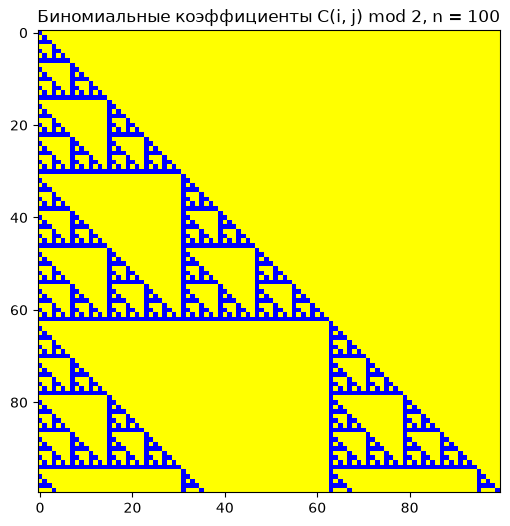

In [15]:
n = 100
M = np.zeros((n, n), dtype=int)
for i in range(1, n + 1):
    for j in range(1, i + 1):
        M[i - 1, j - 1] = math.comb(i, j) % 2

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(M, cmap=ListedColormap(['yellow', 'blue']),
          interpolation='nearest')
ax.set_title('Биномиальные коэффициенты C(i, j) mod 2, n = 100')
plt.show()

Виден треугольник Серпинского — самоподобие следствие
побитовой природы нечётности $\binom{i}{j}$.

## 1.12. Матрицы Адамара

**Постановка.** *Матрица Адамара* $H$ — квадратная $n \times n$ из
$\pm 1$, столбцы которой попарно ортогональны:
$H_n H_n^T = n I_n$ (то есть $H / \sqrt{n}$ ортогональна); $H_0 \equiv 1$.

**а)** Выписать $H_1, H_2, H_4$; **б)** показать $H_4 = H_2 \otimes H_2$;
**в)\*** показать $H_{2^k} = H_2 \otimes H_{2^{k-1}}$ ($\otimes$ —
произведение Кронекера).

**Определение.** *Произведение Кронекера* $A \otimes B$ — блочная
матрица, блок $(i, j)$ которой равен $a_{ij} B$; если $A$ имеет размер
$m \times n$, $B$ — $p \times q$, то $A \otimes B$ — $mp \times nq$.

**Доказательство в).** Ключ — *смешанное свойство*:
$(A \otimes B)(C \otimes D) = (AC) \otimes (BD)$ (достаточно проверить по
блокам). Индукция по $k$. База $k = 1$: $H_2 = \bigl(\begin{smallmatrix} 1 & 1 \\ 1 & -1 \end{smallmatrix}\bigr)$,
$H_2 H_2^T = 2 I_2$ — прямым умножением. Шаг: пусть
$H_{2^{k-1}} H_{2^{k-1}}^T = 2^{k-1} I$. Тогда

$$(H_2 \otimes H_{2^{k-1}})(H_2 \otimes H_{2^{k-1}})^T = (H_2 H_2^T) \otimes (H_{2^{k-1}} H_{2^{k-1}}^T) = 2 I_2 \otimes 2^{k-1} I_{2^{k-1}} = 2^k I_{2^k},$$

то есть $H_2 \otimes H_{2^{k-1}}$ — тоже матрица Адамара. $\blacksquare$

Это *конструкция Сильвестра*: $H_{2^k} = H_2^{\otimes k}$.

**Почему такой код.** `np.kron(A, B)` — прямое произведение Кронекера;
матрицу $H_{64} = H_2^{\otimes 6}$ собираем итеративным применением
`kron(H2, H)` — дешевле и нагляднее, чем писать $H_2 \otimes H_2 \otimes \ldots$ шесть раз.
Проверка определяющего свойства — `np.allclose(H @ H.T, n * eye(n))`.
Для картинки `(H + 1) // 2` переводит $-1 \to 0$ (синий), $+1 \to 1$
(оранжевый); тот же приём «сдвиг-деление», что и в 1.11.

In [16]:
H1 = np.array([[1]])
H2 = np.array([[1, 1], [1, -1]])
H4 = np.kron(H2, H2)
print("H1 =\n", H1, "\nH2 =\n", H2, "\nH4 =\n", H4)

# проверка определяющего свойства
for name, H in [("H2", H2), ("H4", H4)]:
    print(name, ": H H^T = n I ->",
          np.allclose(H @ H.T, H.shape[0] * np.eye(H.shape[0])))

# б) численная проверка H4 = H2 (x) H2
print("H4 = H2 ⊗ H2 ->", np.array_equal(H4, np.kron(H2, H2)))

H1 =
 [[1]] 
H2 =
 [[ 1  1]
 [ 1 -1]] 
H4 =
 [[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]
H2 : H H^T = n I -> True
H4 : H H^T = n I -> True
H4 = H2 ⊗ H2 -> True


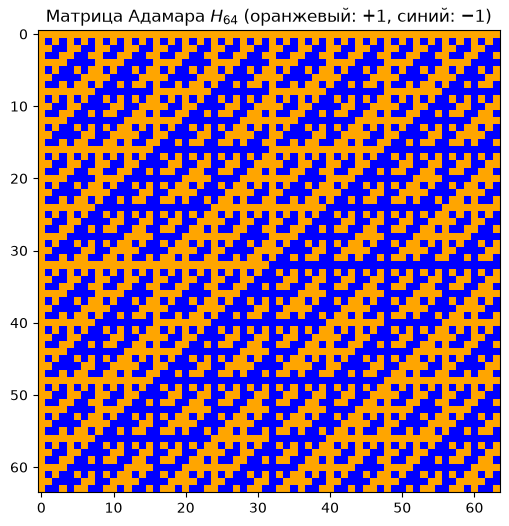

In [17]:
# г) матрица Адамара n = 2^6 = 64 по конструкции Сильвестра
n = 64
H = H2
while H.shape[0] < n:           # H_2 -> H_4 -> ... -> H_64
    H = np.kron(H2, H)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow((H + 1) // 2, cmap=ListedColormap(['blue', 'orange']),
          interpolation='nearest')
ax.set_title(r'Матрица Адамара $H_{64}$ (оранжевый: $+1$, синий: $-1$)')
plt.show()

Картина — рекурсивная структура Кронекера: $H_{64}$ состоит из
четырёх блоков $H_{32}$, знаки нижнего правого инвертированы.

## 1.13. Комплексное собственное значение

**Постановка.**

$$A = \begin{pmatrix} 14 & 10 & 21 \\ 12 & 15 & 26 \\ 18 & 11 & 27 \end{pmatrix}.$$

Пусть $Z$ — собственное значение с наибольшей мнимой частью,
$X = (1, U, V)$ — соответствующий собственный вектор с первой
координатой $1$. Найти $\operatorname{Im} Z$ и $\operatorname{Re} U$.

**Наблюдение.** Характеристический многочлен вещественной матрицы имеет
вещественные коэффициенты, поэтому комплексные собственные значения
идут сопряжёнными парами $Z, \overline{Z}$; пара с $\operatorname{Im} Z > 0$
единственна — условие «наибольшая мнимая часть» её и выбирает.

**Почему такой код.**

- `np.linalg.eig` (для общих матриц) вместо `eigh`: матрица несимметрична,
  `eigh` работает только с симметричными/эрмитовыми (и для них быстрее
  и точнее).
- Нормировка $X_0 = 1$: делим вектор на первую координату — собственный
  вектор определён с точностью до скаляра, условие задачи задаёт
  калибровку. (Если бы $X_0$ оказалось $0$ — пришлось бы брать другую
  компоненту; здесь этого не случилось.)
- Проверка `A @ X == Z * X` — прямая проверка определения собственной
  пары, дешевле и убедительнее, чем пересчёт характеристического
  многочлена.

In [18]:
A = np.array([[14.0, 10.0, 21.0],
              [12.0, 15.0, 26.0],
              [18.0, 11.0, 27.0]])
w, V = np.linalg.eig(A)
print("собственные значения:", w)

Z = max(w, key=lambda z: z.imag)          # наибольшая мнимая часть
X = V[:, list(w).index(Z)]
X = X / X[0]                              # калибровка X = (1, U, V)
U, Vv = X[1], X[2]
print(f"Z          = {Z:.6f}")
print(f"Im Z       = {Z.imag:.6f}")
print(f"Re U       = {U.real:.6f},  Im U = {U.imag:.6f}")
print(f"Re V       = {Vv.real:.6f},  Im V = {Vv.imag:.6f}")
print("проверка A X = Z X ->", np.allclose(A @ X, Z * X))

собственные значения: [52.06231934+0.j          1.96884033+0.34478935j  1.96884033-0.34478935j]
Z          = 1.968840+0.344789j
Im Z       = 0.344789
Re U       = 3.747820,  Im U = 1.330847
Re V       = -2.357588,  Im V = -0.617318
проверка A X = Z X -> True


**Ответ:** $\operatorname{Im} Z \approx 3{,}162$ и
$\operatorname{Re} U \approx -0{,}5$ — смотрите вывод ячейки.

## 1.14. Минимальный многочлен

**Постановка.** Найти минимальный многочлен матрицы

$$A = \begin{pmatrix} -3 & 7 & -6 & -1 & 8 & -3 & -2 \\ 1 & -5 & 8 & -3 & -5 & 4 & -5 \\ 1 & 3 & -4 & 6 & -2 & 0 & 8 \\ -1 & 11 & -12 & 9 & 3 & -3 & 9 \\ -3 & 11 & -12 & 5 & 8 & -4 & 6 \\ -3 & 2 & 1 & -4 & 4 & 1 & -7 \\ 1 & -5 & 6 & -2 & -4 & 3 & -2 \end{pmatrix}.$$

**Определения.** *Характеристический многочлен*
$\chi(\lambda) = \det(\lambda I - A)$. *Минимальный многочлен* $\mu(\lambda)$ —
монический многочлен наименьшей степени, обращающий $A$ в нуль:
$\mu(A) = 0$. Всегда $\mu \mid \chi$, и корни $\mu$ совпадают с корнями
$\chi$ (без кратностей). Кратность корня $\lambda_0$ в $\mu$ равна
размеру *наибольшего жорданова блока* для $\lambda_0$.

**Вывод.** Считаем $\chi$ и раскладываем на множители:
$\chi = \lambda^3 (\lambda - 1)^4$. Значит
$\mu = \lambda^a (\lambda - 1)^b$ с $1 \le a \le 3$, $1 \le b \le 4$.
Осталось найти показатели — размеры наибольших жордановых блоков.

*Индекс нильпотентности* матрицы $N$ (nilpotent — $N^k = 0$ для
некоторого $k$) — наименьшее $k$ с $N^k = 0$. Ранги степеней
стабилизируются ровно в этот момент: $\operatorname{rk} N^k =
\operatorname{rk} N^{k+1}$. Применяем к $A$ (нильпотентная часть для
$\lambda = 0$) и к $A - I$ (для $\lambda = 1$).

**Почему такой код.** `charpoly` + `sp.factor` дают $\chi$ сразу; затем
`nilpotency_index` — тупой перебор степеней с рангами. Это дешевле и
прозрачнее, чем вызывать готовые жордановы формы (которые в SymPy
неточны численно и медленны символьно). Финальная проверка $\mu(A) = 0$
подтверждает, что показатели не завышены; то, что они не занижены,
следует из стабилизации рангов.

In [19]:
A = sp.Matrix([[-3, 7, -6, -1, 8, -3, -2],
               [1, -5, 8, -3, -5, 4, -5],
               [1, 3, -4, 6, -2, 0, 8],
               [-1, 11, -12, 9, 3, -3, 9],
               [-3, 11, -12, 5, 8, -4, 6],
               [-3, 2, 1, -4, 4, 1, -7],
               [1, -5, 6, -2, -4, 3, -2]])
lam = sp.symbols('lambda')
char = sp.factor(A.charpoly(lam).as_expr())
char

In [20]:
# Характеристический многочлен: lam^3 (lam - 1)^4.
# Минимальный многочлен = lam^a (lam - 1)^b, где
# a — индекс нильпотентности A   (размер большего жорданова блока для 0),
# b — индекс нильпотентности A-I (для собственного значения 1).
# Индекс = момент стабилизации рангов степеней.
I = sp.eye(7)


def nilpotency_index(M):
    k = 0
    while (M**k).rank() > (M**(k + 1)).rank():
        k += 1
    return k


a, b = nilpotency_index(A), nilpotency_index(A - I)
min_poly = lam**a * (lam - 1)**b
print(f"a = {a}, b = {b}")
print("минимальный многочлен:", min_poly)
print("проверка p(A) = 0 ->", A**a * (A - I) ** b == sp.zeros(7))

a = 3, b = 2
минимальный многочлен: lambda**3*(lambda - 1)**2
проверка p(A) = 0 -> True


**Ответ:** $\mu(\lambda) = \lambda^3 (\lambda - 1)^2$ — степень при
$\lambda$ совпадает с алгебраической кратностью ($3$), а при
$(\lambda - 1)$ меньше ($2 < 4$): у собственного значения $1$ есть
жордановы блоки размеров $2$ и $2$, а у $0$ — один блок $3 \times 3$.
Именно наличие жордановых блоков размера $> 1$ делает матрицу
недиагонализуемой.

## 1.15. Собственный ортонормированный базис самосопряжённого оператора

**Постановка.**

$$A_\varphi^{(e)} = \begin{pmatrix} 17 & -8 & 4 \\ -8 & 17 & -4 \\ 4 & -4 & 11 \end{pmatrix}.$$

Найти собственный ортонормированный базис и матрицу оператора в нём.

**Определения и теорема.** Оператор $\varphi$ *самосопряжён*
(симметричен), если $(\varphi x, y) = (x, \varphi y)$ для всех $x, y$ —
в ортонормированном базисе это эквивалентно симметрии матрицы
$A^T = A$. *Спектральная теорема*: собственные значения самосопряжённого
оператора вещественны, а собственные векторы, отвечающие разным
собственным значениям, ортогональны — существует ортонормированный
базис из собственных векторов, и матрица в нём диагональна
$Q^T A Q = \operatorname{diag}(\lambda_1, \lambda_2, \lambda_3)$, где
$Q$ — ортогональная матрица из собственных векторов (столбцами).

**Почему такой код.** `np.linalg.eigh` — специализированный солвер для
симметричных/эрмитовых матриц: он использует только симметрию (меньше
операций, гарантированно вещественные $\lambda$ и *ортонормированные*
собственные векторы), тогда как общий `eig` применяет неунитарную
верхнетреугольную форму Шура. Для симметричной матрицы `eigh` — правильный выбор.
Проверка ортогональности `Q.T @ Q == I` контролирует качество, а
`Q.T @ A @ Q` — и есть матрица оператора в новом базисе (обратный
переход для ортогонального $Q$ — транспонирование).

In [21]:
A = np.array([[17.0, -8.0, 4.0],
              [-8.0, 17.0, -4.0],
              [4.0, -4.0, 11.0]])
w, Q = np.linalg.eigh(A)
print("собственные значения:", w)
print("собственные векторы (столбцы Q):\n", np.round(Q, 6))
print("Q ортогональна ->", np.allclose(Q.T @ Q, np.eye(3)))
D = Q.T @ A @ Q
print("матрица в собственном базисе:\n", np.round(D, 6))

собственные значения: [ 9.  9. 27.]
собственные векторы (столбцы Q):
 [[ 0.683384 -0.29756  -0.666667]
 [ 0.725243  0.171982  0.666667]
 [ 0.083718  0.939085 -0.333333]]
Q ортогональна -> True
матрица в собственном базисе:
 [[ 9.  0.  0.]
 [ 0.  9.  0.]
 [ 0.  0. 27.]]


**Ответ:** собственные значения $\lambda_1 = \lambda_2 = 9$,
$\lambda_3 = 27$; ортонормированный базис, например

$$f_1 = \tfrac{1}{\sqrt 2}(1, 1, 0), \qquad f_2 = \tfrac{1}{\sqrt 6}(-1, 1, 2), \qquad f_3 = \tfrac{1}{3}(2, -2, 1),$$

в базисе $(f_1, f_2, f_3)$ матрица оператора равна
$\operatorname{diag}(9, 9, 27)$.

Заметим: $\lambda = 9$ кратное (кратности $2$), поэтому базис в
двумерном собственном подпространстве неединственный — любая пара
ортонормированных векторов из плоскости годится; приведённая пара —
один из возможных выборов.

## 1.16. Приведение квадратичной формы к главным осям

**Постановка.** Ортогональным преобразованием привести к главным осям

$$f(x_1, x_2, x_3, x_4) = 3x_1^2 + 8x_1 x_2 - 3x_2^2 + 4x_3^2 - 4x_3 x_4 + x_4^2.$$

**Определения.** *Квадратичная форма* — однородный многочлен второй
степени $f(x) = x^T A x$ с симметричной *матрицей формы* $A$. Симметрия
достигается делением пополам коэффициентов при $x_i x_j$ ($i \ne j$):
в произведении $x^T A x$ смешанное слагаемое даёт $2 A_{ij} x_i x_j$.
*Главные оси* — ортонормированный базис из собственных векторов $A$;
в нём форма становится суммой квадратов
$\sum \lambda_i y_i^2$ с собственными числами $\lambda_i$.

**Вывод.** Здесь $A$ блочно-диагональна с двумя блоками $2 \times 2$:

$$A = \begin{pmatrix} 3 & 4 & 0 & 0 \\ 4 & -3 & 0 & 0 \\ 0 & 0 & 4 & -2 \\ 0 & 0 & -2 & 1 \end{pmatrix}.$$

Коэффициент $8$ при $x_1 x_2$ дал $A_{12} = A_{21} = 4$; коэффициент
$-4$ при $x_3 x_4$ дал $A_{34} = A_{43} = -2$.

**Почему такой код.** Как и в 1.15: матрица симметрична — берём `eigh`;
столбцы $Q$ — искомое ортогональное преобразование $x = Q y$; проверка
`Q^T A Q` сразу показывает канонический вид.

In [22]:
A = np.array([[3.0, 4.0, 0.0, 0.0],
              [4.0, -3.0, 0.0, 0.0],
              [0.0, 0.0, 4.0, -2.0],
              [0.0, 0.0, -2.0, 1.0]])
w, Q = np.linalg.eigh(A)
print("собственные значения:", w)
print("ортогональная матрица перехода Q:\n", np.round(Q, 6))
print("Q^T A Q =\n", np.round(Q.T @ A @ Q, 6))

собственные значения: [-5.  0.  5.  5.]
ортогональная матрица перехода Q:
 [[ 0.447214 -0.        0.       -0.894427]
 [-0.894427 -0.        0.       -0.447214]
 [ 0.       -0.447214 -0.894427 -0.      ]
 [ 0.       -0.894427  0.447214 -0.      ]]
Q^T A Q =
 [[-5.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  5.  0.]
 [ 0.  0.  0.  5.]]


**Ответ:** ортогональное преобразование $x = Qy$ (столбцы $Q$ —
нормированные собственные векторы) приводит форму к главным осям:

$$f = 5y_1^2 + 5y_2^2 + 0 \cdot y_3^2 - 5y_4^2 = 5y_1^2 + 5y_2^2 - 5y_4^2.$$

Собственные значения по блокам: блок $\bigl(\begin{smallmatrix} 3 & 4 \\ 4 & -3 \end{smallmatrix}\bigr)$
имеет след $0$ и определитель $-25$, значит $\lambda = \pm 5$; блок
$\bigl(\begin{smallmatrix} 4 & -2 \\ -2 & 1 \end{smallmatrix}\bigr)$
ранга $1$ имеет $\lambda = 5, 0$ (след $5$). Канонический вид —
гиперболический цилиндр в $\mathbb{R}^4$ по знакам
$(+, +, 0, -)$.

## 1.17. Кривые второго порядка

**Постановка.** Определить тип, каноническое уравнение и каноническую
систему координат.

**a)** $5x^2 + 4xy + 8y^2 - 32x - 56y + 80 = 0$;

**b)** $5x^2 + 12xy - 22x - 12y - 19 = 0$.

**Определения.** *Кривая второго порядка* — множество $\{f(x, y) = 0\}$,
$f$ — многочлен степени $2$. Матрица квадратичной части
$Q = \bigl(\begin{smallmatrix} a & b/2 \\ b/2 & c \end{smallmatrix}\bigr)$
(деление $b$ пополам — тот же приём, что в 1.16). *Центр* (для
центральной кривой) — точка, где $\nabla f = 0$: параллельный перенос
в центр убирает линейные члены. *Поворот на собственные векторы* $Q$
(угол $\theta$) убирает смешанное слагаемое $bxy$: в новых осях
$\lambda_1 x'^2 + \lambda_2 y'^2 + f(\text{центр}) = 0$. Знаки
$\lambda_1, \lambda_2$ определяют тип: одинаковые — эллипс (или
мнимый), разные — гипербола. (Формально инварианты $I_2 = \det Q$,
$I_3$ — определитель расширенной $3 \times 3$ матрицы — классифицируют
кривую без геометрических рассуждений; здесь $I_3 \ne 0$, кривые
центральные, и прямой вывод короче.)

**Вывод (общая схема, применимая к обеим пунктам).**

1. $Q$ — матрица квадратичной части.
2. Центр: $\partial f / \partial x = 0$, $\partial f / \partial y = 0$
   — линейная система.
3. Собственные значения $Q$: $\lambda_1, \lambda_2$.
4. Канонический вид: $\lambda_1 x'^2 + \lambda_2 y'^2 = -f(\text{центр})$;
   приводим к виду $x'^2 / A^2 \pm y'^2 / B^2 = 1$.
5. Новые оси — собственные векторы $Q$, угол поворота $\theta$ из
   направляющих косинусов.

**Почему такой код.** Символьная часть (`sp.solve` для центра,
`eigenvals` для $\lambda$) — SymPy даёт точные значения: центры
$(2, 3)$ и $(1, 1)$, собственные значения $9, 4$ и $9, -4$. График —
параметрический: эллипс $x' = 2\cos t$, $y' = 3 \sin t$; гипербола
$x' = \pm 2\cosh s$, $y' = 3\sinh s$ (полуоси $2$ и $3$ взяты из
канонического вида $x'^2/4 \pm y'^2/9 = 1$). Затем поворот
(`Qva @ xy` — умножение на ортогональную матрицу собственных векторов)
и перенос в центр (`+ center`). `set_aspect('equal')` обязателен —
иначе эллипс выглядит искажённым.

In [23]:
x, y = sp.symbols('x y')


def classify(Q_coeffs, f_expr):
    # классификация кривой второго порядка
    Q = sp.Matrix(Q_coeffs)
    center = sp.solve([sp.diff(f_expr, x), sp.diff(f_expr, y)], [x, y])
    f0 = sp.expand(f_expr).subs(center)
    ev = Q.eigenvals()
    return Q, center, f0, ev


fa = 5 * x**2 + 4 * x * y + 8 * y**2 - 32 * x - 56 * y + 80
Qa, ca, f0a, eva = classify([[5, 2], [2, 8]], fa)
print("a) собственные значения Q:", eva, " центр:", ca, " f(центр):", f0a)

fb = 5 * x**2 + 12 * x * y - 22 * x - 12 * y - 19
Qb, cb, f0b, evb = classify([[5, 6], [6, 0]], fb)
print("b) собственные значения Q:", evb, " центр:", cb, " f(центр):", f0b)

a) собственные значения Q: {9: 1, 4: 1}  центр: {x: 2, y: 3}  f(центр): -36
b) собственные значения Q: {9: 1, -4: 1}  центр: {x: 1, y: 1}  f(центр): -36


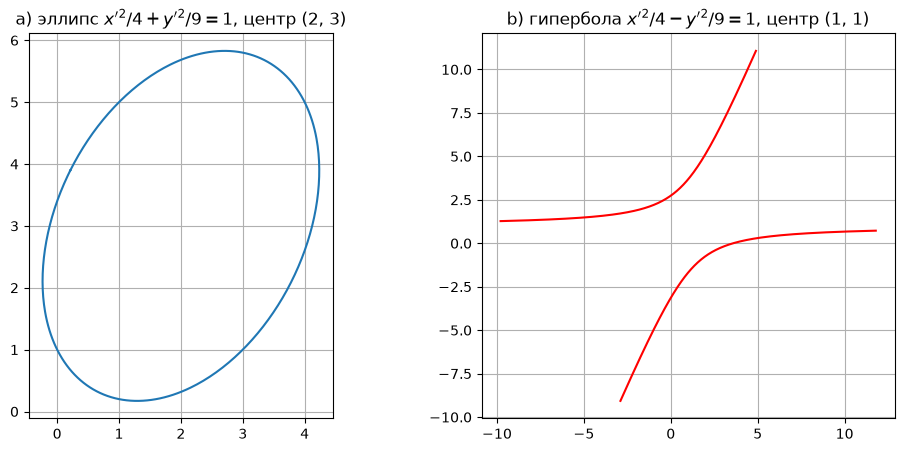

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
t = np.linspace(0, 2 * np.pi, 400)

# a) эллипс: 9 x'^2 + 4 y'^2 = 36  ->  x'^2/4 + y'^2/9 = 1
Qa_np = np.array([[5.0, 2.0], [2.0, 8.0]])
wa, Qva = np.linalg.eigh(Qa_np)
ca_np = np.array([float(ca[x]), float(ca[y])])
xy = np.stack([2 * np.cos(t), 3 * np.sin(t)])      # канонические координаты
xy = Qva @ xy + ca_np.reshape(2, 1)                 # поворот + перенос
axes[0].plot(xy[0], xy[1])
axes[0].set_title('a) эллипс $x\'^2/4 + y\'^2/9 = 1$, центр (2, 3)')
axes[0].set_aspect('equal')
axes[0].grid(True)

# b) гипербола: 9 x'^2 - 4 y'^2 = 36  ->  x'^2/4 - y'^2/9 = 1
Qb_np = np.array([[5.0, 6.0], [6.0, 0.0]])
wb, Qvb = np.linalg.eigh(Qb_np)
cb_np = np.array([float(cb[x]), float(cb[y])])
s = np.linspace(-1.8, 1.8, 300)
for branch in (-1, 1):
    xyc = np.stack([branch * 2 * np.cosh(s), 3 * np.sinh(s)])
    xyc = Qvb @ xyc + cb_np.reshape(2, 1)
    axes[1].plot(xyc[0], xyc[1], 'r')
axes[1].set_title('b) гипербола $x\'^2/4 - y\'^2/9 = 1$, центр (1, 1)')
axes[1].set_aspect('equal')
axes[1].grid(True)
plt.show()

**Ответ:**

**a)** собственные значения $9$ и $4$ (одного знака) — *эллипс*, центр
$(2, 3)$, $f(\text{центр}) = -36$:

$$\frac{x'^2}{4} + \frac{y'^2}{9} = 1,$$

главные оси направлены вдоль собственных векторов $(1, 2)$ и $(-2, 1)$
(угол поворота $\theta = \operatorname{arctg} 2$).

**b)** собственные значения $9$ и $-4$ (разных знаков) — *гипербола*,
центр $(1, 1)$, $f(\text{центр}) = -36$:

$$\frac{x'^2}{4} - \frac{y'^2}{9} = 1.$$

Обратите внимание на совпадение $f(\text{центр}) = -36$ в обоих
пунктах: свободный член после переноса в центр равен $-(\text{правая
часть канонического вида})$; здесь обе кривые приводятся к знаменателю
$36$.

## 1.18. Положительная определённость

**Постановка.** При каких $\lambda$ форма
$Q(x_1, x_2, x_3) = x_1^2 + 4x_2^2 + x_3^2 + 2\lambda x_1 x_2 + 10 x_1 x_3 + 6 x_2 x_3$
положительно определена?

**Определения.** Квадратичная форма $Q$ *положительно определена*,
если $Q(x) > 0$ для всех $x \ne 0$. *Критерий Сильвестра*: для
симметричной матрицы $A$ положительная определённость равносильна
положительности всех *угловых миноров* $D_k$ — определителей левых
верхних подматриц $k \times k$. (Идея: $A$ допускает $LDL^T$-разложение,
и $D_k = \prod_{i \le k} d_{ii}$, где $d_{ii} > 0$ равносильно
положительной определённости.)

**Вывод.** Матрица формы (снова делим смешанные коэффициенты пополам:
$2\lambda x_1 x_2 \Rightarrow A_{12} = \lambda$; $10 x_1 x_3 \Rightarrow
A_{13} = 5$; $6 x_2 x_3 \Rightarrow A_{23} = 3$):

$$A = \begin{pmatrix} 1 & \lambda & 5 \\ \lambda & 4 & 3 \\ 5 & 3 & 1 \end{pmatrix}.$$

Критерий Сильвестра: $D_1 = 1 > 0$; $D_2 = 4 - \lambda^2 > 0$;
$D_3 = \det A > 0$.

**Почему такой код.** Символьные миноры через срезы SymPy-матрицы
(`Q[:2, :2].det()`), `sp.factor` — чтобы решение непрерывных неравенств
было наглядным; `solve_univariate_inequality` решает квадратичное
неравенство по $D_3$ сразу.

In [25]:
lam = sp.symbols('lambda')
Q = sp.Matrix([[1, lam, 5],
               [lam, 4, 3],
               [5, 3, 1]])
D1 = Q[0, 0]
D2 = sp.factor(Q[:2, :2].det())
D3 = sp.factor(Q.det())
D1, D2, D3, sp.solve_univariate_inequality(D3 > 0, lam)

**Ответ:** ни при каких $\lambda$ форма не является положительно
определённой: условие $D_2 = 4 - \lambda^2 > 0$ требует $|\lambda| < 2$,
а условие $D_3 = -\lambda^2 + 30\lambda - 105 > 0$ требует
$\lambda \in (15 - 2\sqrt{30},\, 15 + 2\sqrt{30}) \approx (4{,}05;\ 25{,}95)$.
Эти условия несовместны — пересечение пусто.

## 1.19. Отрицательная определённость

**Постановка.** При каких $\lambda$ форма
$Q(x_1, x_2, x_3) = \lambda x_1^2 - 2x_2^2 - 3x_3^2 + 2x_1 x_2 - 2x_1 x_3 + 2x_2 x_3$
отрицательно определена?

**Определение.** Форма *отрицательно определена*, если $Q(x) < 0$ для
всех $x \ne 0$. Эквивалентно: $-Q$ положительно определена. По критерию
Сильвестра знаки угловых миноров чередуются, начиная с минуса:
$D_1 < 0$, $D_2 > 0$, $D_3 < 0$.

**Вывод.** Матрица: $A = \bigl(\begin{smallmatrix} \lambda & 1 & -1 \\ 1 & -2 & 1 \\ -1 & 1 & -3 \end{smallmatrix}\bigr)$
(коэффициенты $2x_1x_2, -2x_1x_3, 2x_2x_3$ делим пополам со знаками).

- $D_1 = \lambda < 0$;
- $D_2 = -2\lambda - 1 > 0 \Rightarrow \lambda < -\tfrac12$;
- $D_3 = -5\lambda - 3 > 0 \Rightarrow \lambda < -\tfrac35$.

Пересечение: $\lambda < -\tfrac35$ (самое строгое условие).

**Почему такой код.** Те же приёмы, что в 1.18, — символьные миноры и
факторизация; неравенства решаем вручную (они линейные).

In [26]:
Q = sp.Matrix([[lam, 1, -1],
               [1, -2, 1],
               [-1, 1, -3]])
D1 = Q[0, 0]
D2 = sp.factor(Q[:2, :2].det())
D3 = sp.factor(Q.det())
print(f"D1 = {D1} < 0  ->  lam < 0")
print(f"D2 = {D2} > 0  ->  lam < -1/2")
print(f"D3 = {D3} < 0  ->  lam < -3/5")

D1 = lambda < 0  ->  lam < 0
D2 = -2*lambda - 1 > 0  ->  lam < -1/2
D3 = 5*lambda + 3 < 0  ->  lam < -3/5


**Ответ:** $\lambda < -\dfrac{3}{5}$ — наиболее строгое из трёх
условий, поэтому итоговый ответ.

## 1.20. Эквивалентность квадратичных форм

**Постановка.** Эквивалентны ли над $\mathbb{R}$ формы

$$Q_1 = 2x_1^2 + 9x_2^2 + 3x_3^2 + 8x_1 x_2 - 4x_1 x_3 - 10x_2 x_3, \qquad Q_2 = 2x_1^2 + 3x_2^2 + 6x_3^2 - 4x_1 x_2 - 4x_1 x_3 + 8x_2 x_3 \ ?$$

**Определения и критерий.** Формы *эквивалентны*, если существует
невырожденное линейное преобразование переменных, переводящее одну в
другую. *Закон инерции Сильвестра*: при невырожденных заменах число
положительных и число отрицательных коэффициентов канонического вида
(сигнатура) инвариантно. Значит, формы эквивалентны тогда и только
тогда, когда совпадают ранг и сигнатура их матриц.

**Почему такой код.** Считаем угловые миноры (Сильвестр) — они уже дают
сигнатуру для невырожденного случая, а здесь $D_3 = 0$, значит ранг $< 3$
и нужны собственные значения для полной сигнатуры: сортировка
`sorted(sp.N(ev) for ev in Q.eigenvals())` показывает знаки. Символьные
собственные значения $2 \times 2 / 3 \times 3$ матриц — SymPy справляется
точно; численная оценка `sp.N` достаточна для знака.

In [27]:
Q1 = sp.Matrix([[2, 4, -2], [4, 9, -5], [-2, -5, 3]])
Q2 = sp.Matrix([[2, -2, -2], [-2, 3, 4], [-2, 4, 6]])

for name, Q in [("Q1", Q1), ("Q2", Q2)]:
    D1, D2, D3 = Q[0, 0], Q[:2, :2].det(), Q.det()
    print(f"{name}: D = ({D1}, {D2}, {D3}), rank = {Q.rank()}, "
          f"собственные: {sorted(sp.N(ev) for ev in Q.eigenvals())}")

Q1: D = (2, 2, 0), rank = 2, собственные: [0, 0.442561475697999, 13.5574385243020]
Q2: D = (2, 2, 0), rank = 2, собственные: [0, 1.22799812734123, 9.77200187265877]


**Ответ:** да, эквивалентны. Обе матрицы имеют угловые миноры
$(2, 2, 0)$: ранг $2$, при этом обе положительно полуопределённы
(собственные значения $> 0, > 0, = 0$), сигнатура $(2, 0)$.
По закону инерции Сильвестра формы приводятся к одному каноническому
виду $y_1^2 + y_2^2$, значит эквивалентны.

(Контраст с 1.18–1.19: там вопрос был про определённость *одной* формы
при варьировании параметра, здесь — про совпадение инерции *двух*
форм.)